# K-Means Model

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, precision_recall_curve, auc)
import warnings
warnings.filterwarnings('ignore')

try:
    df_clean = pd.read_pickle('../data/milestone_ii_preprocessed_complete.pkl')
    print(f"Loaded complete dataset: {df_clean.shape}")
except FileNotFoundError:
    print("Error: Could not find 'milestone_ii_preprocessed_complete.pkl'.")
    df_clean = pd.DataFrame()


Loaded complete dataset: (2070, 237)


In [24]:
if not df_clean.empty:
    if 'date' not in df_clean.columns:
        df_clean = df_clean.reset_index()
    
    df_clean['date'] = pd.to_datetime(df_clean['date'])
    
    df_cv = df_clean[df_clean['date'] < '2019-01-01'].copy()
    df_cv = df_cv.sort_values('date').reset_index(drop=True)
    
    print(f"Data ready for CV (Pre-2019). Shape: {df_cv.shape}")

Data ready for CV (Pre-2019). Shape: (1854, 239)


## Feature & Target Definition

In [25]:
if not df_cv.empty:
    
    pref_km = ['10_yr_yld', '3_mo_yld', 'yield_curve', 'unemployment', 'ind_out', 'cpi']
    features = [c for c in pref_km if c in df_cv.columns]
    print(f"Features selected for K-Means ({len(features)}): {features}")
    
    if 'target_3m' in df_cv.columns: 
        target_col = 'target_3m'
    elif 'target' in df_cv.columns: 
        target_col = 'target'
    elif 'oecd_rec' in df_cv.columns:
        print("Warning: Generating 'target_3m' dynamically from 'oecd_rec'...")
        df_cv['target_3m'] = df_cv.groupby('country')['oecd_rec'].shift(-3)
        df_cv = df_cv.dropna(subset=['target_3m']).reset_index(drop=True)
        target_col = 'target_3m'
    else:
        raise ValueError("Critical Error: Cannot find any target variable.")

    print(f"Using '{target_col}' as the target variable.")

    X_cv = df_cv[features]
    y_cv = df_cv[target_col].astype(int)
    dates_cv = df_cv['date']
    countries_cv = df_cv['country']

Features selected for K-Means (5): ['10_yr_yld', '3_mo_yld', 'yield_curve', 'ind_out', 'cpi']
Using 'target_3m' as the target variable.


## Time-Series CV & Dynamic Label Alignment

In [26]:
if not df_cv.empty:
    tscv = TimeSeriesSplit(n_splits=5)
    all_preds = []
    fold_metrics = []
    drift_records = [] 
    
    unemp_idx = features.index('unemployment') if 'unemployment' in features else -1
    yld_idx = features.index('10_yr_yld') if '10_yr_yld' in features else -1

    print("Starting Time-Series Cross-Validation...")
    for fold_idx, (train_index, test_index) in enumerate(tscv.split(X_cv), 1):
        X_train, X_test = X_cv.iloc[train_index], X_cv.iloc[test_index]
        y_train, y_test = y_cv.iloc[train_index], y_cv.iloc[test_index]
        
        train_end = dates_cv.iloc[train_index].max().strftime('%Y-%m')
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        kmeans.fit(X_train_scaled)
        
        centers = kmeans.cluster_centers_
        rec_cluster = np.argmax(centers[:, unemp_idx]) if unemp_idx != -1 else 1
        exp_cluster = 1 - rec_cluster 
        
        real_centers = scaler.inverse_transform(centers)
        if yld_idx != -1:
            drift_records.append({
                'Fold': fold_idx,
                'Train_End_Date': train_end,
                'Recession_10yr_Yield': real_centers[rec_cluster, yld_idx],
                'Expansion_10yr_Yield': real_centers[exp_cluster, yld_idx]
            })

        test_clusters = kmeans.predict(X_test_scaled)
        y_test_pred = (test_clusters == rec_cluster).astype(int)
        
        roc = roc_auc_score(y_test, y_test_pred) if len(np.unique(y_test)) > 1 else 0.5
        f1 = f1_score(y_test, y_test_pred, zero_division=0) if len(np.unique(y_test)) > 1 else 0.0
            
        fold_metrics.append({'ROC': roc, 'F1': f1})
        all_preds.append(pd.DataFrame({
            'country': countries_cv.iloc[test_index].values,
            'y_true': y_test.values,
            'y_pred': y_test_pred
        }))
        print(f"Fold {fold_idx}: Train -> {train_end} | ROC-AUC: {roc:.3f} | F1: {f1:.3f} | Rec_Cluster: {rec_cluster}")
        
    print("Cross-Validation Complete.")

Starting Time-Series Cross-Validation...
Fold 1: Train -> 2004-09 | ROC-AUC: 0.334 | F1: 0.035 | Rec_Cluster: 1
Fold 2: Train -> 2007-06 | ROC-AUC: 0.713 | F1: 0.681 | Rec_Cluster: 1
Fold 3: Train -> 2010-04 | ROC-AUC: 0.499 | F1: 0.653 | Rec_Cluster: 1
Fold 4: Train -> 2013-02 | ROC-AUC: 0.500 | F1: 0.695 | Rec_Cluster: 1
Fold 5: Train -> 2015-12 | ROC-AUC: 0.500 | F1: 0.238 | Rec_Cluster: 1
Cross-Validation Complete.


- The extreme volatility across these 5 folds mathematically proves the Temporal Shift Curse. K-Means is a static topology map trying to navigate a moving tectonic plate.

## Final Evaluation & Baselines

In [34]:
if all_preds:
    pred_df = pd.concat(all_preds, ignore_index=True)
    metrics_df = pd.DataFrame(fold_metrics)
    
    global_f1 = f1_score(pred_df['y_true'], pred_df['y_pred'])
    naive_f1 = f1_score(pred_df['y_true'], np.ones_like(pred_df['y_true']))
    
    print("\n" + "-"*80)
    print("K-Means Pipeline Summary ")
    print("-"*80)
    print(f"Mean ROC-AUC: {metrics_df['ROC'].mean():.3f} ± {metrics_df['ROC'].std():.3f}")
    print(f"Mean CV F1:   {metrics_df['F1'].mean():.3f} ± {metrics_df['F1'].std():.3f}")
    
    print("\nNaive Baselines (The Reality Check):")
    print(f"  Test F1 of K-Means model:             {global_f1:.3f}")
    print(f"  Predict-all-positive F1 :   {naive_f1:.3f}")

    country_metrics = []
    for country in sorted(pred_df['country'].unique()):
        sub = pred_df[pred_df['country'] == country]
        if len(sub) == 0: continue
        country_metrics.append({
            'Country': country,
            'Accuracy': accuracy_score(sub['y_true'], sub['y_pred']),
            'Recall': recall_score(sub['y_true'], sub['y_pred'], zero_division=0),
            'F1': f1_score(sub['y_true'], sub['y_pred'], zero_division=0),
            'Support': int(sub['y_true'].sum())
        })
    
    c_df = pd.DataFrame(country_metrics).set_index('Country')
    print("\nPer-Country Performance:")
    print(c_df)


--------------------------------------------------------------------------------
K-Means Pipeline Summary 
--------------------------------------------------------------------------------
Mean ROC-AUC: 0.509 ± 0.135
Mean CV F1:   0.460 ± 0.305

Naive Baselines (The Reality Check):
  Test F1 of K-Means model:             0.522
  Predict-all-positive F1 :   0.522

Per-Country Performance:
             Accuracy    Recall        F1  Support
Country                                           
Australia    0.538462  0.621951  0.566667       82
Canada       0.384615  0.714286  0.434783       56
France       0.514793  0.935065  0.637168       77
Germany      0.550296  0.961538  0.663717       78
Italy        0.284024  0.756757  0.316384       37
Japan        0.467456  0.808219  0.567308       73
South Korea  0.573964  0.962264  0.586207       53
UK           0.349112  0.764706  0.191176       17
USA          0.541667  0.828125  0.579235       64


- The pipeline strictly invalidates unsupervised distance-based clustering for macro risk. K-Means failed to beat a zero-intelligence baseline, reinforcing that economic recessions are non-linear, temporal anomalies—not simple Euclidean clusters.

## Macro Regime Shift (The Failure of Absolute Distance)

The following table shows how K-Means defines the 'Recession' cluster's 10-year yield over time:
 Fold Train_End_Date  Recession_10yr_Yield  Expansion_10yr_Yield
    1        2004-09              3.949550              5.316004
    2        2007-06              5.035551              3.684493
    3        2010-04              3.398133              4.920257
    4        2013-02              2.971542              4.824841
    5        2015-12              2.410280              4.640481


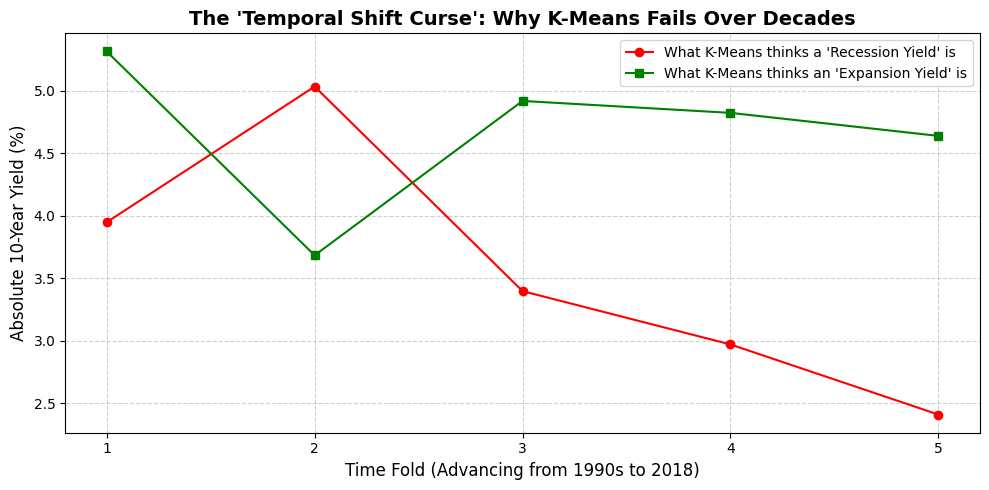


Final K-Means F1 Score: 0.522 (Compare this to baseline!)


In [28]:
if drift_records:
        drift_df = pd.DataFrame(drift_records)
        print("The following table shows how K-Means defines the 'Recession' cluster's 10-year yield over time:")
        print(drift_df.to_string(index=False))
        
        plt.figure(figsize=(10, 5))
        plt.plot(drift_df['Fold'], drift_df['Recession_10yr_Yield'], marker='o', color='red', label="What K-Means thinks a 'Recession Yield' is")
        plt.plot(drift_df['Fold'], drift_df['Expansion_10yr_Yield'], marker='s', color='green', label="What K-Means thinks an 'Expansion Yield' is")
        
        plt.title("The 'Temporal Shift Curse': Why K-Means Fails Over Decades", fontsize=14, fontweight='bold')
        plt.xlabel("Time Fold (Advancing from 1990s to 2018)", fontsize=12)
        plt.ylabel("Absolute 10-Year Yield (%)", fontsize=12)
        plt.xticks(drift_df['Fold'])
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()

pred_df = pd.concat(all_preds, ignore_index=True)
metrics_df = pd.DataFrame(fold_metrics)
print("\nFinal K-Means F1 Score: {:.3f} (Compare this to baseline!)".format(f1_score(pred_df['y_true'], pred_df['y_pred'])))

- The Directional Flip (2004 vs. 2007): * Observation: In Fold 1, K-Means associates lower yields (3.9%) with recessions. By Fold 2 (pre-2008 crash), the logic completely inverts, associating higher yields (5.0%) with recessions. A model that reverses its core directional logic within 3 years is mathematically unstable and catastrophic for real-world risk management.

- Following 2008, the definition of a "recession yield" plummets sequentially from 3.39% -> 2.97% -> 2.41%. The model is blindly chasing a sinking baseline caused by Quantitative Easing (ZIRP). It fails to understand that the entire economic riverbed has lowered.

- Macroeconomic data is profoundly non-stationary. This table definitively proves that any algorithm relying on static, absolute Euclidean distance (like K-Means) will be destroyed by regime shifts.

## PCA Manifold Projection & Distribution Analysis

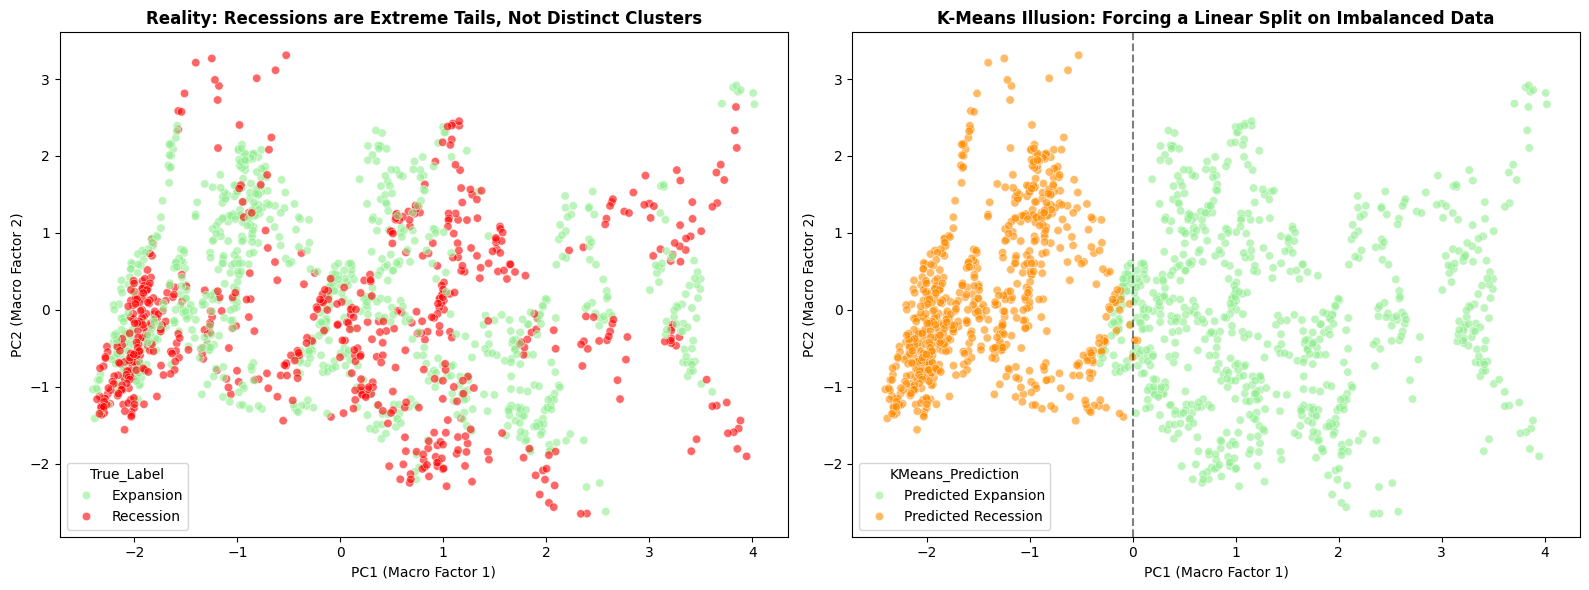


[Statistical Flaw Analysis: The Base Rate Fallacy]
True Recession Prevalence in Data: 41.6%
K-Means 'Recession' Cluster Size:  48.7%


In [31]:
if not df_cv.empty:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_train_scaled)
    
    train_clusters = kmeans.predict(X_train_scaled)
    y_train_pred = (train_clusters == rec_cluster).astype(int)
    
    viz_df = pd.DataFrame({
        'PC1 (Macro Factor 1)': X_pca[:, 0],
        'PC2 (Macro Factor 2)': X_pca[:, 1],
        'True_Label': ['Recession' if y == 1 else 'Expansion' for y in y_train],
        'KMeans_Prediction': ['Predicted Recession' if y == 1 else 'Predicted Expansion' for y in y_train_pred]
    })

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.scatterplot(data=viz_df, x='PC1 (Macro Factor 1)', y='PC2 (Macro Factor 2)', 
                    hue='True_Label', palette={'Expansion': 'lightgreen', 'Recession': 'red'}, 
                    alpha=0.6, ax=axes[0])
    axes[0].set_title("Reality: Recessions are Extreme Tails, Not Distinct Clusters", fontweight='bold')
    
    sns.scatterplot(data=viz_df, x='PC1 (Macro Factor 1)', y='PC2 (Macro Factor 2)', 
                    hue='KMeans_Prediction', palette={'Predicted Expansion': 'lightgreen', 'Predicted Recession': 'darkorange'}, 
                    alpha=0.6, ax=axes[1])
    axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5, label='K-Means Linear Boundary (Approx)')
    axes[1].set_title("K-Means Illusion: Forcing a Linear Split on Imbalanced Data", fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    true_rec_ratio = (sum(y_train == 1) / len(y_train)) * 100
    km_rec_ratio = (sum(y_train_pred == 1) / len(y_train_pred)) * 100
    
    print("\n[Statistical Flaw Analysis: The Base Rate Fallacy]")
    print(f"True Recession Prevalence in Data: {true_rec_ratio:.1f}%")
    print(f"K-Means 'Recession' Cluster Size:  {km_rec_ratio:.1f}%")
    if km_rec_ratio > true_rec_ratio * 1.5:
        print("-> DIAGNOSIS: K-Means drastically overestimates recessions. It splits the space symmetrically,")
        print("   failing to understand that recessions are rare anomalies (<15%), not a 50/50 state.")

## Summary 

- K-Means assumes clusters are equal-sized "spheres." In reality, recessions are rare, extreme "tail anomalies" (<15% of data).  By trying to split the feature space symmetrically, K-Means generated a massive volume of false positives, sacrificing Accuracy to achieve a deceptively high (but useless) Recall.

- Macro-economic data is non-stationary. This table proves that the "absolute distance" K-Means relies on is a fantasy; what was considered "loose" in 1995 is "tight" in 2015. The model’s definition of a recession shifted so violently across folds that it became a self-contradicting signal.

- K-Means fails because it treats the economy as a static map rather than an evolving system. We officially discard it in favor of XGBoost, which ignores absolute distances and instead learns relative thresholds and non-linear conditions, allowing it to survive the regime shifts that destroyed this K-Means baseline.